# H3 Binning - Chicago Rideshare Demand

## H3 Hexagonal Binning — Uber's Spatial Index

### What is H3?
H3 is a hierarchical hexagonal grid system created by Uber for spatial analysis. It divides the world into hexagonal cells at 16 resolution levels (0 = continent-sized, 15 = sub-meter).

### Why hexagons?
- **Equal neighbors:** Every hexagon touches exactly 6 neighbors.
- **Consistent distance:** The center-to-center distance is the same in all directions.
- **Better for movement:** Human movement doesn't follow grid lines — hexagons approximate circles better than squares

### Resolution for rideshare:
| Resolution | Hex Edge Length | Hex Area | Use Case |
|---|---|---|---|
| 7 | ~1.2 km | ~5.2 km² | City-district level |
| 8 | ~460 m | ~0.74 km² | Neighborhood level |
| **9** | **~174 m** | **~0.1 km²** | **~2 city blocks** |
| 10 | ~66 m | ~0.015 km² | Individual intersections |

In [2]:
import h3
import json
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import branca.colormap as cm
import folium
from folium import Element

In [3]:
print(f"H3 version: {h3.__version__}")

lat = 41.8819  # The Loop
lon = -87.6278
for res in [7, 8, 9, 10]:
    hex_id = h3.latlng_to_cell(lat, lon, res)
    boundary = h3.cell_to_boundary(hex_id)
    area = h3.cell_area(hex_id, unit='km^2')
    print(f"  Resolution {res}: {hex_id}  |  Area: {area:.4f} km²  |  Vertices: {len(boundary)}")

H3 version: 4.4.2
  Resolution 7: 872664c1affffff  |  Area: 5.2044 km²  |  Vertices: 6
  Resolution 8: 882664c1a9fffff  |  Area: 0.7436 km²  |  Vertices: 6
  Resolution 9: 892664c1a83ffff  |  Area: 0.1062 km²  |  Vertices: 6
  Resolution 10: 8a2664c1a827fff  |  Area: 0.0152 km²  |  Vertices: 6


In [4]:
def add_context_box(folium_map, title, subtitle, stats_dict, color_info=None, position='topright'):
    """
    context/legend box to a Folium map.
    
    Parameters:
    - folium_map: the folium.Map object
    - title: bold heading (e.g., "Demand Heatmap")
    - subtitle: one-liner description
    - stats_dict: dict of {label: value} pairs to display
    - color_info: list of (color_hex, label) tuples for legend
    - position: 'topright', 'topleft', 'bottomright', 'bottomleft'
    """
    
    pos_css = {
        'topright':    'top: 15px; right: 15px;',
        'topleft':     'top: 15px; left: 15px;',
        'bottomright': 'bottom: 30px; right: 15px;',
        'bottomleft':  'bottom: 30px; left: 15px;'
    }
    
    stats_html = ''
    for label, value in stats_dict.items():
        stats_html += f'''
            <div style="display: flex; justify-content: space-between; 
                        padding: 4px 0; border-bottom: 1px solid rgba(255,255,255,0.1);">
                <span style="color: #aaa; font-size: 12px;">{label}</span>
                <span style="color: #fff; font-size: 12px; font-weight: bold;">{value}</span>
            </div>'''
    
    # Build color legend
    legend_html = ''
    if color_info:
        legend_html = '<div style="margin-top: 10px; padding-top: 8px; border-top: 1px solid rgba(255,255,255,0.2);">'
        legend_html += '<div style="color: #888; font-size: 10px; margin-bottom: 5px; text-transform: uppercase; letter-spacing: 1px;">Color Scale</div>'
        for color_hex, label in color_info:
            legend_html += f'''
                <div style="display: flex; align-items: center; margin: 3px 0;">
                    <div style="width: 18px; height: 10px; background: {color_hex}; 
                                border-radius: 2px; margin-right: 8px; flex-shrink: 0;"></div>
                    <span style="color: #ccc; font-size: 11px;">{label}</span>
                </div>'''
        legend_html += '</div>'
    
    html = f'''
    <div style="
        position: fixed; {pos_css.get(position, pos_css['topright'])}
        z-index: 9999;
        background: rgba(15, 15, 25, 0.92);
        backdrop-filter: blur(10px);
        border: 1px solid rgba(255,255,255,0.15);
        border-radius: 10px;
        padding: 18px 22px;
        max-width: 300px;
        font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif;
        box-shadow: 0 8px 32px rgba(0,0,0,0.5);
    ">
        <div style="font-size: 16px; font-weight: 700; color: #fff; margin-bottom: 2px;">
            {title}
        </div>
        <div style="font-size: 11px; color: #888; margin-bottom: 12px; line-height: 1.4;">
            {subtitle}
        </div>
        {stats_html}
        {legend_html}
        <div style="margin-top: 10px; font-size: 9px; color: #555; text-align: center;">
            Chicago Rideshare · December 2024
        </div>
    </div>
    '''
    
    folium_map.get_root().html.add_child(Element(html))
    return folium_map


def add_landmark_markers(folium_map):
    """subtle landmark markers for geographic context."""
    
    landmarks = {
        'The Loop':         (41.8819, -87.6278, '🏢'),
        'O\'Hare Airport':  (41.9742, -87.9073, '✈️'),
        'Midway Airport':   (41.7868, -87.7522, '✈️'),
        'Lake View':        (41.9434, -87.6553, '🏘️'),
        'Wicker Park':      (41.9088, -87.6796, '🎸'),
        'Hyde Park':        (41.7943, -87.5907, '🎓'),
        'Navy Pier':        (41.8917, -87.6086, '🎡'),
    }
    
    for name, (lat, lon, emoji) in landmarks.items():
        folium.map.Marker(
            [lat, lon],
            icon=folium.DivIcon(html=f'''
                <div style="font-size: 11px; color: rgba(255,255,255,0.7); 
                     text-shadow: 1px 1px 3px black; white-space: nowrap;
                     font-family: -apple-system, sans-serif;">
                    {emoji} {name}
                </div>''')
        ).add_to(folium_map)
    
    return folium_map

# 
##### Assign H3 Index to Every Trip

In [5]:
df = pd.read_parquet("/Volumes/T7/DS Projects/Chicago Ride Demand Forecasting/data/processed/chirde.with_features.parquet")

df_geo = df.dropna(subset=['pickup_centroid_latitude', 'pickup_centroid_longitude']).copy()
df_geo = df_geo.rename(columns={
    'pickup_centroid_latitude': 'latitude',
    'pickup_centroid_longitude': 'longitude'
})

# Chicago downtown coordinates
CHICAGO_CENTER = {
    'latitude': 41.8781,
    'longitude': -87.6298
}

H3_RESOLUTION = 8

start = time.time()

# Assigning neighborhood level to each trip
df_geo['h3_index'] = df_geo.apply(lambda row: h3.latlng_to_cell(row['latitude'], row['longitude'], H3_RESOLUTION), axis=1)

##### H3 Cell Trip Counts
Aggregating trips into H3 cells gives a clean spatial unit for analysis. Each cell represents a consistent ~0.74 km2 hexagonal area.

In [6]:
h3_counts = df_geo.groupby('h3_index').agg(trip_count = ('h3_index', 'size'), avg_fare = ('fare', 'mean'), avg_duration_min = ('trip_seconds', lambda x: x.mean() / 60), avg_distance = ('trip_miles', 'mean'), tip_rate = ('tip', lambda x: (x > 0).mean() * 100)).reset_index()

# Get center latitude/longitude fo each H3 cell
h3_counts['latitude'] = h3_counts['h3_index'].apply(lambda h: h3.cell_to_latlng(h)[0])
h3_counts['longitude'] = h3_counts['h3_index'].apply(lambda h: h3.cell_to_latlng(h)[1])

h3_counts['avg_fare'] = h3_counts['avg_fare'].round(2)
h3_counts['avg_duration_min'] = h3_counts['avg_duration_min'].round(1)
h3_counts['avg_distance'] = h3_counts['avg_distance'].round(2)
h3_counts['tip_rate'] = h3_counts['tip_rate'].round(1)

# Top Busiest H3 cells
top10 = h3_counts.nlargest(10, 'trip_count')
for _, row in top10.iterrows():
    print(f"  {row['h3_index']}  |  {row['trip_count']:>7,} trips  | avg fare: ${row['avg_fare']:.2f}  |  avg dist: {row['avg_distance']:.1f} mi")

  882664c1e1fffff  |  178,118 trips  | avg fare: $11.42  |  avg dist: 1.9 mi
  882664c1e3fffff  |  174,957 trips  | avg fare: $11.00  |  avg dist: 2.0 mi
  882664c1a9fffff  |  171,708 trips  | avg fare: $11.40  |  avg dist: 2.2 mi
  882664c1edfffff  |  127,160 trips  | avg fare: $11.38  |  avg dist: 2.7 mi
  882664cad7fffff  |  122,848 trips  | avg fare: $12.47  |  avg dist: 2.2 mi
  882664c1adfffff  |  116,190 trips  | avg fare: $10.75  |  avg dist: 2.0 mi
  882664c1e7fffff  |  100,067 trips  | avg fare: $11.52  |  avg dist: 1.8 mi
  882664c1e5fffff  |   86,066 trips  | avg fare: $10.46  |  avg dist: 1.7 mi
  882664c163fffff  |   81,845 trips  | avg fare: $9.91  |  avg dist: 2.5 mi
  882664c1abfffff  |   75,625 trips  | avg fare: $10.95  |  avg dist: 2.2 mi


##### H3 Demand Distribution

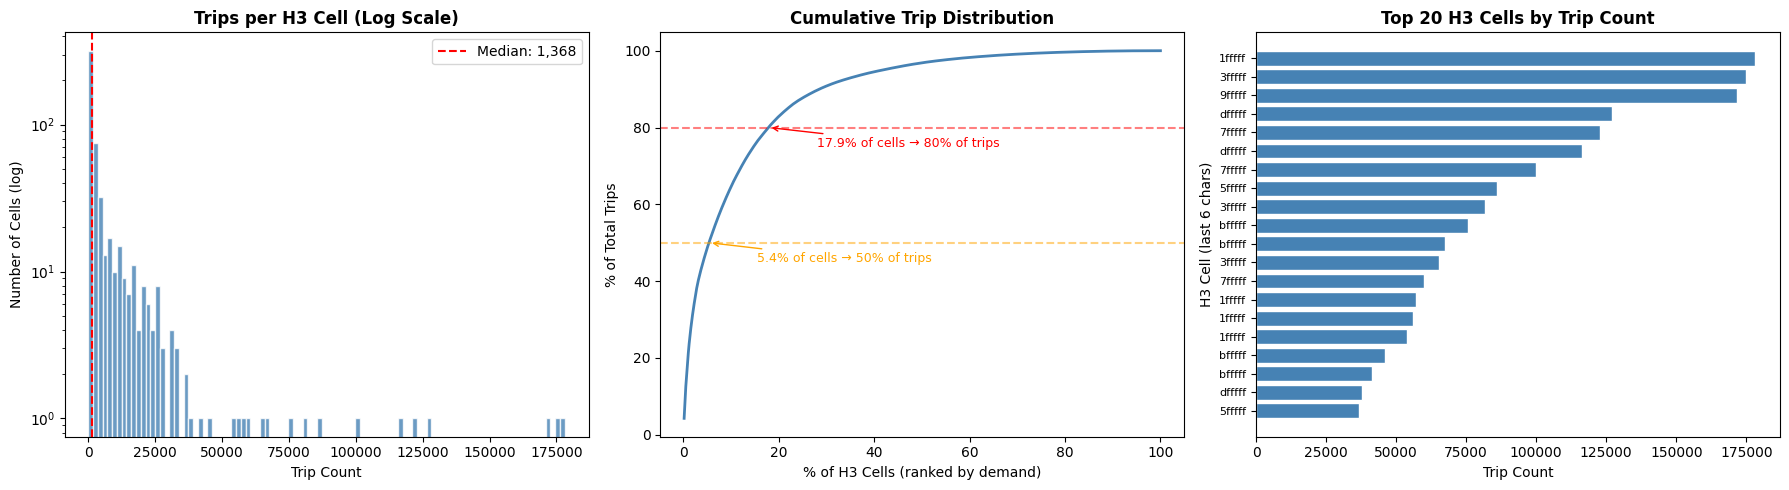

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

ax[0].hist(h3_counts['trip_count'], bins=100, color='steelblue', edgecolor='white', alpha=0.8)
ax[0].set_yscale('log')
ax[0].set_title('Trips per H3 Cell (Log Scale)', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Trip Count')
ax[0].set_ylabel('Number of Cells (log)')
ax[0].axvline(h3_counts['trip_count'].median(), color='red', linestyle='--',
                label=f'Median: {h3_counts["trip_count"].median():,.0f}')
ax[0].legend()

sorted_counts = h3_counts['trip_count'].sort_values(ascending=False).values
cumulative_pct = np.cumsum(sorted_counts) / sorted_counts.sum() * 100
cell_pct = np.arange(1, len(sorted_counts) + 1) / len(sorted_counts) * 100

ax[1].plot(cell_pct, cumulative_pct, color='steelblue', linewidth=2)
ax[1].set_title('Cumulative Trip Distribution', fontsize=12, fontweight='bold')
ax[1].set_xlabel('% of H3 Cells (ranked by demand)')
ax[1].set_ylabel('% of Total Trips')
ax[1].axhline(80, color='red', linestyle='--', alpha=0.5)
ax[1].axhline(50, color='orange', linestyle='--', alpha=0.5)

# x values where y crosses 50% and 80%
idx_50 = np.searchsorted(cumulative_pct, 50)
idx_80 = np.searchsorted(cumulative_pct, 80)
pct_cells_50 = cell_pct[idx_50]
pct_cells_80 = cell_pct[idx_80]

ax[1].annotate(f'{pct_cells_50:.1f}% of cells → 50% of trips',
                 xy=(pct_cells_50, 50), fontsize=9, color='orange',
                 xytext=(pct_cells_50 + 10, 45),
                 arrowprops=dict(arrowstyle='->', color='orange'))
ax[1].annotate(f'{pct_cells_80:.1f}% of cells → 80% of trips',
                 xy=(pct_cells_80, 80), fontsize=9, color='red',
                 xytext=(pct_cells_80 + 10, 75),
                 arrowprops=dict(arrowstyle='->', color='red'))

top20 = h3_counts.nlargest(20, 'trip_count')
ax[2].barh(range(20), top20['trip_count'].values[::-1], color='steelblue', edgecolor='white')
ax[2].set_yticks(range(20))
ax[2].set_yticklabels([h[-6:] for h in top20['h3_index'].values[::-1]], fontsize=8)
ax[2].set_title('Top 20 H3 Cells by Trip Count', fontsize=12, fontweight='bold')
ax[2].set_xlabel('Trip Count')
ax[2].set_ylabel('H3 Cell (last 6 chars)')

plt.tight_layout()
plt.show()

##### H3 Hexagonal Demand Map
Each H3 cell rendered as an actual hexagon on the map, colored by trip density. This is the signature visualization of spatial demand analysis — it shows you the exact hexagonal grid that our model will use as geographic features.

In [8]:
def h3_to_geojson(h3_data, value_column='trip_count'):
    """Convert H3 cell data to GeoJSON for Folium/Plotly."""
    features = []
    for _, row in h3_data.iterrows():
        # Get hexagon boundary vertices
        boundary = h3.cell_to_boundary(row['h3_index'])
        coords = [[lng, lat] for lat, lng in boundary]
        coords.append(coords[0])

        feature = {
            'type': 'Feature',
            'geometry': {
                'type': 'Polygon',
                'coordinates': [coords]
            },
            'properties': {
                'h3_index': row['h3_index'],
                'trip_count': int(row['trip_count']),
                'avg_fare': float(row['avg_fare']),
                'avg_duration_min': float(row['avg_duration_min']),
                'avg_distance': float(row['avg_distance']),
                'tip_rate': float(row['tip_rate'])
            }
        }
        features.append(feature)
    
    return {'type': 'FeatureCollection', 'features': features}

# Filter to cells with meaningful activity
MIN_TRIPS = 200
active_cells = h3_counts[h3_counts['trip_count'] >= MIN_TRIPS].copy()
print(f"Cells with >= {MIN_TRIPS} trips: {len(active_cells):,} out of {len(h3_counts):,}")
print(f"These cells contain {active_cells['trip_count'].sum():,} trips "
      f"({active_cells['trip_count'].sum()/h3_counts['trip_count'].sum()*100:.1f}% of total)")

geojson_data = h3_to_geojson(active_cells)
print(f"GeoJSON features created: {len(geojson_data['features']):,}")

Cells with >= 200 trips: 490 out of 569
These cells contain 4,169,883 trips (99.8% of total)
GeoJSON features created: 490


In [9]:
max_trips = active_cells['trip_count'].quantile(0.95)  # 95th percentile for better color spread
colormap = cm.LinearColormap(
    colors=['#0d0887', '#5b02a3', '#9c179e', '#cc4778', '#ed7953', '#f0f921'],
    vmin=MIN_TRIPS,
    vmax=max_trips,
    caption='Trip Count per H3 Cell'
)

m = folium.Map(location=[CHICAGO_CENTER['latitude'], CHICAGO_CENTER['longitude']], zoom_start=11, tiles='CartoDB dark_matter')

folium.GeoJson(
    geojson_data,
    style_function=lambda feature: {
        'fillColor': colormap(min(feature['properties']['trip_count'], max_trips)),
        'color': 'white',
        'weight': 0.3,
        'fillOpacity': 0.7
    },
    tooltip=folium.GeoJsonTooltip(
        fields=['h3_index', 'trip_count', 'avg_fare', 'avg_duration_min', 'avg_distance', 'tip_rate'],
        aliases=['H3 Cell:', 'Total Trips:', 'Avg Fare ($):', 'Avg Duration (min):', 'Avg Distance (mi):', 'Tip Rate (%):'],
        style='background-color: rgba(15,15,25,0.9); color: white; font-family: monospace; font-size: 12px; padding: 8px;',
        sticky=True
    ),
    highlight_function=lambda x: {
        'weight': 2,
        'color': '#ffffff',
        'fillOpacity': 0.9
    }
).add_to(m)
colormap.add_to(m)

add_landmark_markers(m)

add_context_box(m,
    title='H3 Hexagonal Demand Map',
    subtitle=f'Each hexagon is an H3 resolution-{H3_RESOLUTION} cell (~0.74 km²). '
             f'Colored by total trip pickups. Hover for details.',
    stats_dict={
        'H3 Resolution': f'{H3_RESOLUTION} (~460m edge)',
        'Active Cells': f'{len(active_cells):,} (≥{MIN_TRIPS} trips)',
        'Total Cells': f'{len(h3_counts):,}',
        'Busiest Cell': f'{active_cells["trip_count"].max():,} trips',
        'Median Cell': f'{active_cells["trip_count"].median():,.0f} trips',
    },
    color_info=[
        ('#f0f921', f'High (>{max_trips:,.0f})'),
        ('#ed7953', 'Above Average'),
        ('#cc4778', 'Average'),
        ('#9c179e', 'Below Average'),
        ('#5b02a3', 'Low'),
        ('#0d0887', f'Minimal ({MIN_TRIPS}+)'),
    ],
    position='topright'
)

m.save('/Volumes/T7/DS Projects/Chicago Ride Demand Forecasting/data/external/maps/07_h3_hexagonal_demand.html')
m

##### H3 Map Colored by Pattern Type

In [10]:
top50_cells = h3_counts.nlargest(50, 'trip_count')['h3_index'].tolist()

# Hourly pattern for each of those cells
hourly_by_cell = df_geo[df_geo['h3_index'].isin(top50_cells)].groupby(
    ['h3_index', 'hour']
).size().unstack(fill_value=0)

hourly_pct = hourly_by_cell.div(hourly_by_cell.sum(axis=1), axis=0) * 100

def classify_pattern(row):
    morning = row[7:10].sum()
    evening = row[17:20].sum()
    late_night = row[22:24].sum() + row[0:3].sum()
    midday = row[10:16].sum()
    
    if morning > 15 and evening > 15:
        return 'Commute'
    elif late_night > 20:
        return 'Nightlife'
    elif midday > 35:
        return 'Daytime'
    elif evening > 20:
        return 'Evening'
    else:
        return 'Mixed'

cell_patterns = hourly_pct.apply(classify_pattern, axis=1)

pattern_colors = {
    'Commute':   '#3498db',
    'Nightlife': '#e74c3c',
    'Daytime':   '#f39c12',
    'Evening':   '#9b59b6',
    'Mixed':     '#2ecc71',
}

pattern_labels = {
    'Commute':   'Commute',
    'Nightlife': 'Nightlife',
    'Daytime':   'Daytime',
    'Evening':   'Evening',
    'Mixed':     'Mixed',
}

top50_data = h3_counts[h3_counts['h3_index'].isin(top50_cells)].copy()
top50_data['pattern'] = top50_data['h3_index'].map(cell_patterns).fillna('Mixed')
top50_data['pattern_label'] = top50_data['pattern'].map(pattern_labels)
top50_data['color'] = top50_data['pattern'].map(pattern_colors)
top50_data = top50_data.reset_index(drop=True)

print(f"Cells: {len(top50_data)}")
print(top50_data['pattern'].value_counts().to_string())

features = []
for _, row in top50_data.iterrows():
    boundary = h3.cell_to_boundary(row['h3_index'])
    coords = [[lng, lat] for lat, lng in boundary]
    coords.append(coords[0])
    
    features.append({
        'type': 'Feature',
        'geometry': {'type': 'Polygon', 'coordinates': [coords]},
        'properties': {
            'h3_index': str(row['h3_index']),
            'trip_count': int(row['trip_count']),
            'avg_fare': float(row['avg_fare']),
            'avg_duration_min': float(row['avg_duration_min']),
            'avg_distance': float(row['avg_distance']),
            'tip_rate': float(row['tip_rate']),
            'pattern': str(row['pattern_label']),
            'color': str(row['color'])
        }
    })

geojson_data = {'type': 'FeatureCollection', 'features': features}

m = folium.Map(
    location=[CHICAGO_CENTER['latitude'], CHICAGO_CENTER['longitude']],
    zoom_start=12,
    tiles='CartoDB dark_matter'
)

folium.GeoJson(
    geojson_data,
    style_function=lambda f: {
        'fillColor': f['properties']['color'],
        'color': 'white',
        'weight': 0.8,
        'fillOpacity': 0.75
    },
    highlight_function=lambda f: {
        'weight': 3,
        'color': '#ffffff',
        'fillOpacity': 0.95
    },
    tooltip=folium.GeoJsonTooltip(
        fields=['pattern', 'trip_count', 'avg_fare', 'avg_duration_min', 'avg_distance', 'tip_rate'],
        aliases=['Pattern:', 'Trips:', 'Avg Fare ($):', 'Duration (min):', 'Distance (mi):', 'Tip Rate (%):'],
        style=(
            'background-color: rgba(15,15,25,0.92); color: white; '
            'font-family: -apple-system, sans-serif; font-size: 12px; '
            'padding: 10px; border-radius: 6px; border: 1px solid rgba(255,255,255,0.2);'
        ),
        sticky=True
    )
).add_to(m)

add_landmark_markers(m)

pattern_stats = top50_data['pattern'].value_counts()
add_context_box(m,
    title='🔷 H3 Cells by Demand Pattern',
    subtitle='Top 50 busiest cells classified by hourly demand shape. Hover for details.',
    stats_dict={pattern_labels.get(k, k): f'{v} cells' for k, v in pattern_stats.items()},
    color_info=[(pattern_colors[k], pattern_labels[k]) for k in pattern_stats.index],
    position='topright'
)

m.save('/Volumes/T7/DS Projects/Chicago Ride Demand Forecasting/data/external/maps/08_h3_pattern_types.html')
m

Cells: 50
pattern
Nightlife    23
Mixed        13
Evening      11
Daytime       2
Commute       1


In [14]:
h3_counts.to_parquet('/Volumes/T7/DS Projects/Chicago Ride Demand Forecasting/data/processed/chirde.h3_features.parquet', index=False)

In [15]:
df_geo.to_parquet('/Volumes/T7/DS Projects/Chicago Ride Demand Forecasting/data/processed/chirde.h3_rides.parquet', index=False)